In [3]:
import numpy as np
import matplotlib.pyplot as plt

class VisualPerceptron:
    def __init__(self, n_features, learning_rate=0.1, n_epochs=20):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        # Store snapshot of parameters after every update
        self.history = []

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, gate_name="Logic Gate"):
        update_count = 0
        self.history = []  # Reset history

        print(f"\n================ Training {gate_name} Gate ================")
        print(f"Initial State -> Weights: {self.weights}, Bias: {self.bias}")

        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0

            for xi, yi in zip(X, y):
                y_hat = self.forward(xi)
                error = yi - y_hat

                if error != 0:
                    misclassified += 1
                    update_count += 1

                    # Weight and Bias Updates
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

                    # Log state for plotting
                    self.history.append({
                        'update': update_count,
                        'epoch': epoch,
                        'sample': xi,
                        'target': yi,
                        'weights': self.weights.copy(),
                        'bias': self.bias
                    })

                    print(f"[Epoch {epoch}] Update #{update_count:2d} | "
                          f"Sample: {xi} | Target: {yi} | Predicted: {y_hat} | "
                          f"New Weights: {np.round(self.weights, 3)} | New Bias: {self.bias:.3f}")

            if misclassified == 0:
                print(f"\nModel Converged at Epoch {epoch} with total {update_count} updates!")
                break

        # Plot all updates in a compact grid after training completes
        self.plot_all_updates_grid(X, y, gate_name)

    def plot_all_updates_grid(self, X, y, gate_name):
        n_updates = len(self.history)
        if n_updates == 0:
            print("No updates were made (data was already perfectly classified).")
            return

        # Calculate grid layout (e.g., 2, 3, or 4 columns wide)
        cols = min(n_updates, 4)
        rows = (n_updates + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
        axes = np.array(axes).reshape(-1)  # Flatten array for easy indexing

        for i, step in enumerate(self.history):
            ax = axes[i]
            w = step['weights']
            b = step['bias']

            # --- 2D Case (AND, OR) ---
            if X.shape[1] == 2:
                for cl in np.unique(y):
                    ax.scatter(X[y == cl, 0], X[y == cl, 1],
                               label=f'Class {cl}' if i == 0 else "", s=70, edgecolors='k')

                x1_vals = np.array([-0.5, 1.5])
                if w[1] != 0:
                    x2_vals = -(w[0] * x1_vals + b) / w[1]
                    ax.plot(x1_vals, x2_vals, 'r--', label='Boundary' if i == 0 else "")
                elif w[0] != 0:
                    ax.axvline(x=-b / w[0], color='r', linestyle='--', label='Boundary' if i == 0 else "")

                ax.set_xlim(-0.5, 1.5)
                ax.set_ylim(-0.5, 1.5)
                ax.set_xlabel('X1', fontsize=9)
                ax.set_ylabel('X2', fontsize=9)

            # --- 1D Case (NOT) ---
            elif X.shape[1] == 1:
                for cl in np.unique(y):
                    ax.scatter(X[y == cl, 0], np.zeros_like(X[y == cl, 0]),
                               label=f'Class {cl}' if i == 0 else "", s=70, edgecolors='k')

                if w[0] != 0:
                    ax.axvline(x=-b / w[0], color='r', linestyle='--', label='Boundary' if i == 0 else "")

                ax.set_xlim(-0.5, 1.5)
                ax.set_ylim(-0.5, 0.5)
                ax.set_xlabel('X', fontsize=9)
                ax.set_yticks([])

            ax.set_title(f"Update #{step['update']} (Epoch {step['epoch']})\n"
                         f"w: {np.round(w, 2)}, b: {round(b, 2)}", fontsize=10)
            ax.grid(True, linestyle=':', alpha=0.6)

        # Hide any unused subplot slots in the grid layout
        for j in range(n_updates, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"{gate_name} Gate - Step-by-Step Decision Boundary Updates", fontsize=14, fontweight='bold', y=1.02)
        fig.tight_layout()
        plt.show()

    def predict(self, X):
        return self.forward(X)


================ Training AND Gate ================
Initial State -> Weights: [0. 0.], Bias: 0.0
[Epoch 1] Update # 1 | Sample: [0 0] | Target: 0 | Predicted: 1 | New Weights: [0. 0.] | New Bias: -0.100
[Epoch 1] Update # 2 | Sample: [1 1] | Target: 1 | Predicted: 0 | New Weights: [0.1 0.1] | New Bias: 0.000
[Epoch 2] Update # 3 | Sample: [0 0] | Target: 0 | Predicted: 1 | New Weights: [0.1 0.1] | New Bias: -0.100
[Epoch 2] Update # 4 | Sample: [0 1] | Target: 0 | Predicted: 1 | New Weights: [0.1 0. ] | New Bias: -0.200
[Epoch 2] Update # 5 | Sample: [1 1] | Target: 1 | Predicted: 0 | New Weights: [0.2 0.1] | New Bias: -0.100
[Epoch 3] Update # 6 | Sample: [0 1] | Target: 0 | Predicted: 1 | New Weights: [0.2 0. ] | New Bias: -0.200
[Epoch 3] Update # 7 | Sample: [1 0] | Target: 0 | Predicted: 1 | New Weights: [0.1 0. ] | New Bias: -0.300
[Epoch 3] Update # 8 | Sample: [1 1] | Target: 1 | Predicted: 0 | New Weights: [0.2 0.1] | New Bias: -0.200

Model Converged at Epoch 4 with total 8 

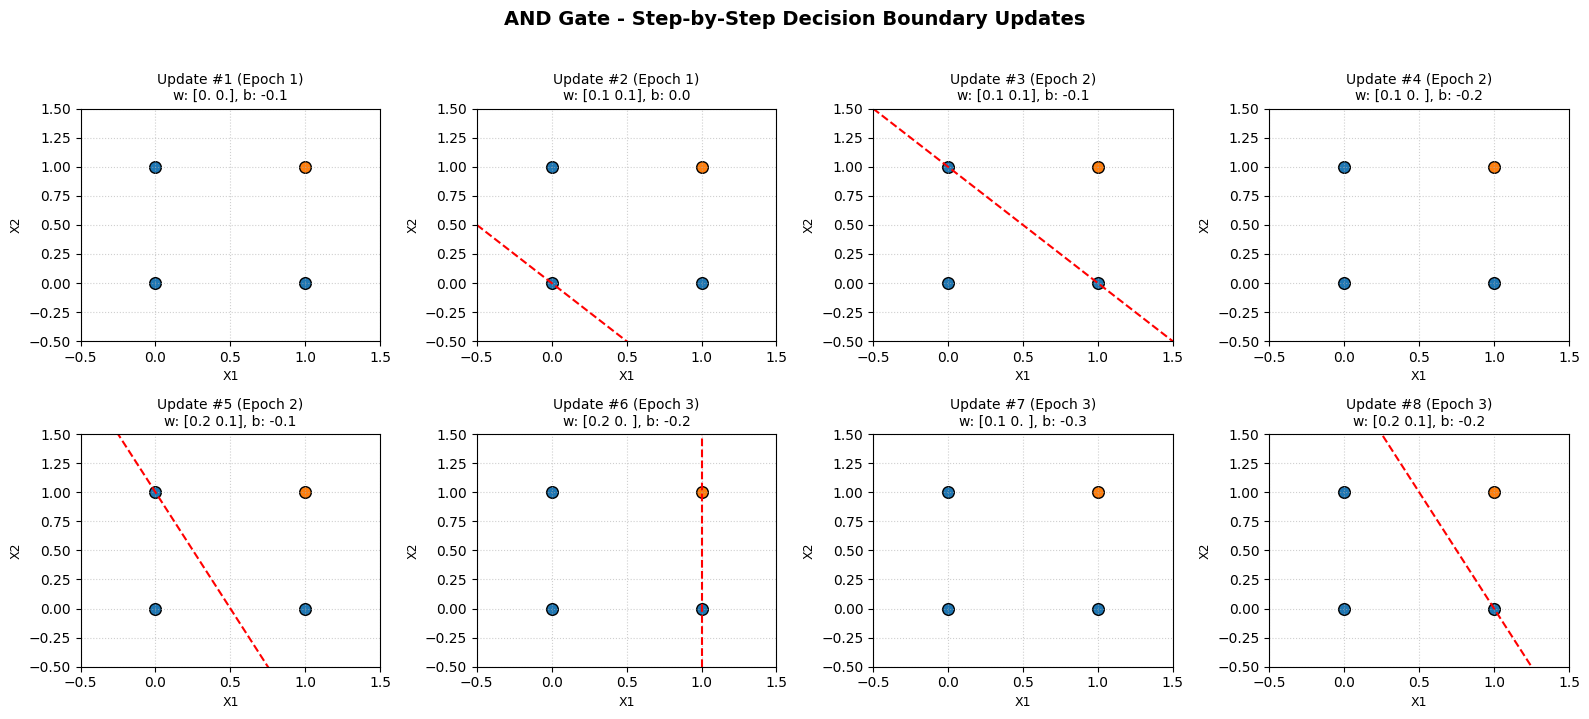


================ Training OR Gate ================
Initial State -> Weights: [0. 0.], Bias: 0.0
[Epoch 1] Update # 1 | Sample: [0 0] | Target: 0 | Predicted: 1 | New Weights: [0. 0.] | New Bias: -0.100
[Epoch 1] Update # 2 | Sample: [0 1] | Target: 1 | Predicted: 0 | New Weights: [0.  0.1] | New Bias: 0.000
[Epoch 2] Update # 3 | Sample: [0 0] | Target: 0 | Predicted: 1 | New Weights: [0.  0.1] | New Bias: -0.100
[Epoch 2] Update # 4 | Sample: [1 0] | Target: 1 | Predicted: 0 | New Weights: [0.1 0.1] | New Bias: 0.000
[Epoch 3] Update # 5 | Sample: [0 0] | Target: 0 | Predicted: 1 | New Weights: [0.1 0.1] | New Bias: -0.100

Model Converged at Epoch 4 with total 5 updates!


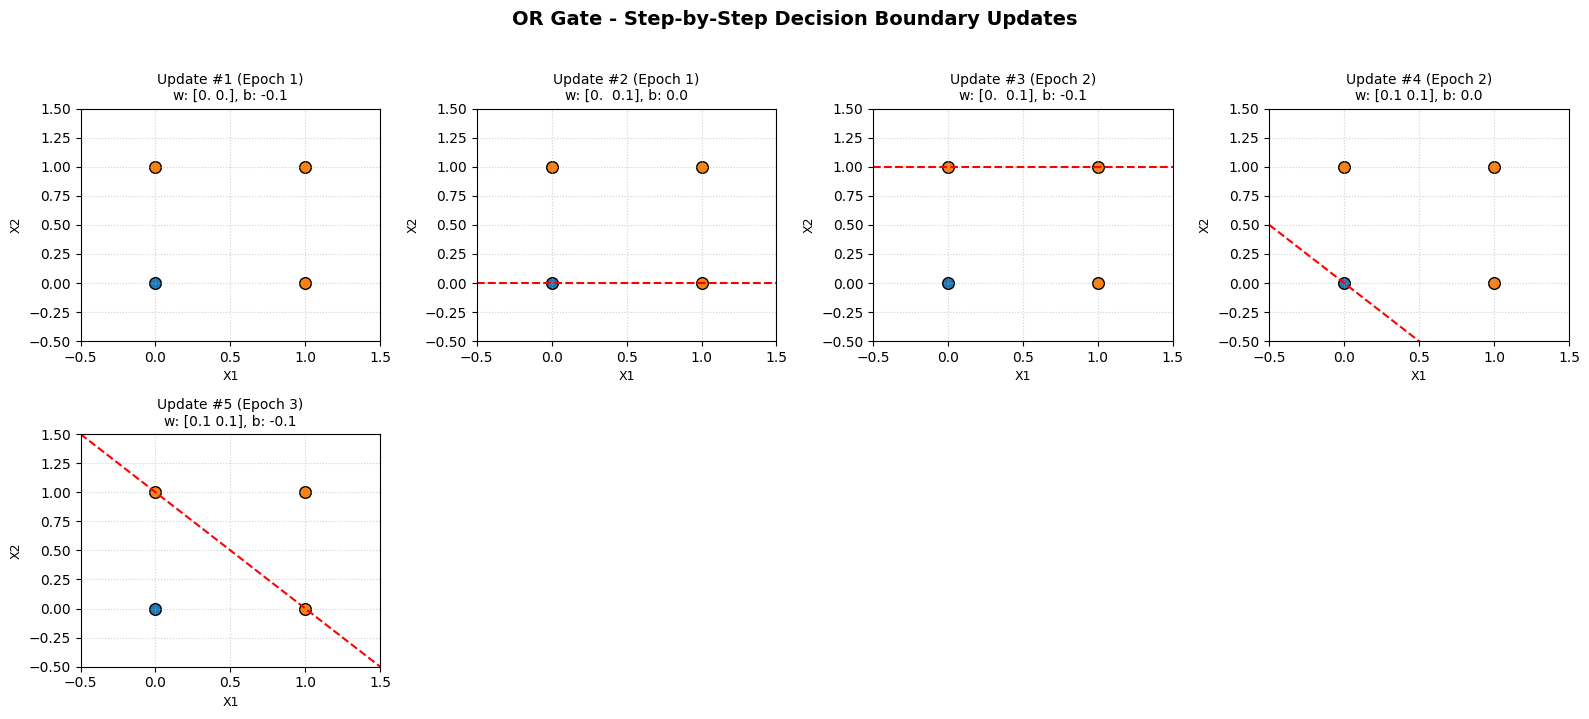


================ Training NOT Gate ================
Initial State -> Weights: [0.], Bias: 0.0
[Epoch 1] Update # 1 | Sample: [1] | Target: 0 | Predicted: 1 | New Weights: [-0.1] | New Bias: -0.100
[Epoch 2] Update # 2 | Sample: [0] | Target: 1 | Predicted: 0 | New Weights: [-0.1] | New Bias: 0.000

Model Converged at Epoch 3 with total 2 updates!


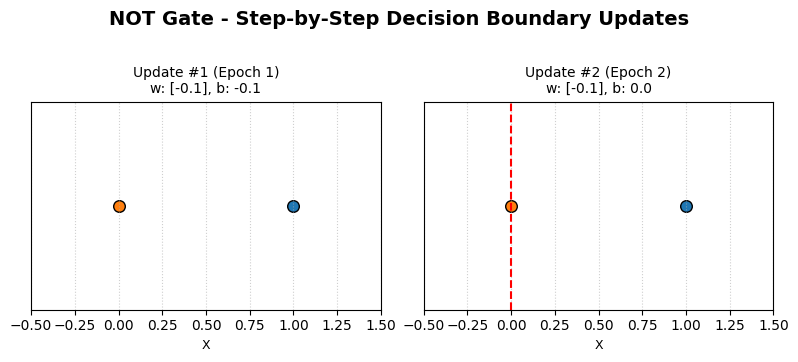

In [4]:
# 1. AND Gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

p_and = VisualPerceptron(n_features=2, learning_rate=0.1)
p_and.fit(X_and, y_and, gate_name="AND")

# 2. OR Gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

p_or = VisualPerceptron(n_features=2, learning_rate=0.1)
p_or.fit(X_or, y_or, gate_name="OR")

# 3. NOT Gate
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

p_not = VisualPerceptron(n_features=1, learning_rate=0.1)
p_not.fit(X_not, y_not, gate_name="NOT")